# Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Load Dataset


In [2]:
df = pd.read_csv('train.csv')
print('Dataset loaded successfully.')
print(f'Shape: {df.shape}')

Dataset loaded successfully.
Shape: (103904, 25)


# Data Understanding

In [3]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())

Shape: (103904, 25)

Columns: ['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [4]:
print('Data Types:')
print(df.dtypes)

Data Types:
Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int6

In [5]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [6]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.499971,64925.349265,39.379697,1189.459963,2.729702,3.060306,2.756872,2.976902,3.202129,3.250385,3.439377,3.358158,3.382401,3.351084,3.631843,3.304290,3.640457,3.286360,14.815387,15.178649
std,29994.645572,37464.812897,15.114955,997.144169,1.327833,1.525078,1.398928,1.277621,1.329525,1.349511,1.319072,1.332991,1.288343,1.315608,1.180910,1.265396,1.175660,1.312282,38.230948,38.698675
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97371.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                          Missing Count  Missing %
Arrival Delay in Minutes            310        0.3


In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

Gender: ['Male' 'Female']
Customer Type: ['Loyal Customer' 'disloyal Customer']
Type of Travel: ['Personal Travel' 'Business travel']
Class: ['Eco Plus' 'Business' 'Eco']
satisfaction: ['neutral or dissatisfied' 'satisfied']


In [9]:
print(df['satisfaction'].value_counts())
print(df['satisfaction'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

satisfaction
neutral or dissatisfied    58878
satisfied                  45026
Name: count, dtype: int64
satisfaction
neutral or dissatisfied    56.67%
satisfied                  43.33%
Name: proportion, dtype: object


# Data Cleaning and Preparation

In [10]:
# Step 1: Drop irrelevant index column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    print('Dropped Unnamed: 0 column.')
else:
    print('No Unnamed column found.')

Dropped Unnamed: 0 column.


In [11]:
# Step 2: Standardize column names to snake_case
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(' ', '_')
              .str.replace('/', '_'))
print('Column names standardized.')
print(df.columns.tolist())


Column names standardized.
['id', 'gender', 'customer_type', 'age', 'type_of_travel', 'class', 'flight_distance', 'inflight_wifi_service', 'departure_arrival_time_convenient', 'ease_of_online_booking', 'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort', 'inflight_entertainment', 'on-board_service', 'leg_room_service', 'baggage_handling', 'checkin_service', 'inflight_service', 'cleanliness', 'departure_delay_in_minutes', 'arrival_delay_in_minutes', 'satisfaction']


In [12]:
# Step 3: Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df)} duplicate rows. Remaining: {len(df)}')

Removed 2 duplicate rows. Remaining: 103902


In [13]:

# Step 4: Fill missing values with median

median_delay = df['arrival_delay_in_minutes'].median()
df['arrival_delay_in_minutes'].fillna(median_delay, inplace=True)
print("Missing values filled with median:", median_delay)
print("Remaining nulls:", df['arrival_delay_in_minutes'].isnull().sum())

Missing values filled with median: 0.0
Remaining nulls: 0


In [14]:
# Step 5: Binary encoding of satisfaction
df['satisfaction_binary'] = (df['satisfaction'] == 'satisfied').astype(int)

print("Encoded: 1 = satisfied, 0 = neutral or dissatisfied")
print(df[['satisfaction', 'satisfaction_binary']].head())

Encoded: 1 = satisfied, 0 = neutral or dissatisfied
              satisfaction  satisfaction_binary
0  neutral or dissatisfied                    0
1  neutral or dissatisfied                    0
2                satisfied                    1
3  neutral or dissatisfied                    0
4                satisfied                    1


In [ ]:
print('Final shape:', df.shape)
print('Total missing values:', df.isnull().sum())

Final shape: (103902, 25)
Total missing values: 0


# Feature Engineering

In [16]:
# Feature 1: Age Group (binning age into categories)
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 30, 45, 60, 100],
    labels=['<18', '18-30', '31-45', '46-60', '60+'],
    right=True,
    include_lowest=True
)

print("Feature 1 - age_group distribution:")
print(df['age_group'].value_counts().to_string())

Feature 1 - age_group distribution:
age_group
31-45    33250
46-60    29919
18-30    23848
<18       8909
60+       7976


In [17]:
# Feature 2: Total Delay
df['total_delay'] = df['departure_delay_in_minutes'] + df['arrival_delay_in_minutes']
print('Feature 2 - total_delay:')
print(df['total_delay'].describe().to_string())

Feature 2 - total_delay:
count    103902.000000
mean         29.949135
std          76.113518
min           0.000000
25%           0.000000
50%           2.000000
75%          24.000000
max        3176.000000


In [18]:
# Feature 3: Average service rating
service_cols = [
    'inflight_wifi_service', 'departure_arrival_time_convenient',
    'ease_of_online_booking', 'gate_location', 'food_and_drink',
    'online_boarding', 'seat_comfort', 'inflight_entertainment',
    'on-board_service', 'leg_room_service', 'baggage_handling',
    'checkin_service', 'inflight_service', 'cleanliness'
]

df['avg_service_rating'] = df[service_cols].mean(axis=1).round(2)

print("Average service rating created")
print(df['avg_service_rating'].describe())

Average service rating created
count    103902.000000
mean          3.240717
std           0.661838
min           1.070000
25%           2.790000
50%           3.290000
75%           3.710000
max           5.000000
Name: avg_service_rating, dtype: float64


In [19]:
# Feature 4: Delay Category
df['delay_category'] = pd.cut(
    df['total_delay'],
    bins=[-1, 0, 30, 120, df['total_delay'].max()],
    labels=['No Delay', 'Minor (1-30 min)', 'Moderate (31-120 min)', 'Severe (>120 min)']
)
print('Delay_category:')
print(df['delay_category'].value_counts().to_string())

Delay_category:
delay_category
No Delay                 47575
Minor (1-30 min)         33407
Moderate (31-120 min)    15741
Severe (>120 min)         7179


# Data Analysis

In [20]:
# Analysis 1 — Satisfaction Rate by Class (Subgroup Comparison 1)
sat_by_class = df.groupby('class')['satisfaction_binary'].mean().mul(100).round(2)
print('Satisfaction Rate by Class (%):')
print(sat_by_class.to_string())

Satisfaction Rate by Class (%):
class
Business    69.42
Eco         18.61
Eco Plus    24.61


In [21]:
# Analysis 2 — Satisfaction Rate by Travel Type (Subgroup Comparison 2)
sat_by_travel = df.groupby('type_of_travel')['satisfaction_binary'].mean().mul(100).round(2)
print('Satisfaction Rate by Travel Type (%):')
print(sat_by_travel.to_string())

Satisfaction Rate by Travel Type (%):
type_of_travel
Business travel    58.26
Personal Travel    10.17


In [22]:
# Analysis 3 — Class x Travel Type Cross-tab
cross = df.groupby(['class', 'type_of_travel'])['satisfaction_binary'].mean().mul(100).round(2).unstack()
print('Satisfaction Rate — Class x Travel Type (%):')
print(cross.to_string())

Satisfaction Rate — Class x Travel Type (%):
type_of_travel  Business travel  Personal Travel
class                                           
Business                  72.02            12.24
Eco                       29.62            10.20
Eco Plus                  39.33             8.71


In [23]:
# Analysis 4: Correlation of service ratings with satisfaction
corr = df[service_cols + ['satisfaction_binary']].corr()['satisfaction_binary']

corr = corr.drop('satisfaction_binary').sort_values(ascending=False)

print("Service rating vs satisfaction correlation:")
print(corr.to_string())

Service rating vs satisfaction correlation:
online_boarding                      0.503555
inflight_entertainment               0.398066
seat_comfort                         0.349464
on-board_service                     0.322364
leg_room_service                     0.313115
cleanliness                          0.305209
inflight_wifi_service                0.284234
baggage_handling                     0.247743
inflight_service                     0.244723
checkin_service                      0.236177
food_and_drink                       0.209953
ease_of_online_booking               0.171699
gate_location                        0.000667
departure_arrival_time_convenient   -0.051608


In [24]:
# Analysis 5 — Average Service Rating by Satisfaction Group
print(df.groupby('satisfaction')['avg_service_rating'].mean().round(2).to_string())

satisfaction
neutral or dissatisfied    2.95
satisfied                  3.62


In [25]:
# Analysis 6 — Mean Total Delay by Satisfaction Group
print(df.groupby('satisfaction')['total_delay'].mean().round(2).to_string())

satisfaction
neutral or dissatisfied    33.58
satisfied                  25.20


In [26]:
# Analysis 7: Outliers in total_delay (IQR method)
Q1, Q3 = df['total_delay'].quantile([0.25, 0.75])
upper_fence = Q3 + 1.5 * (Q3 - Q1)

outliers = df[df['total_delay'] > upper_fence]

print(f"IQR Upper fence: {upper_fence:.1f} min")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(outliers['satisfaction'].value_counts().to_string())

IQR Upper fence: 60.0 min
Outliers: 14287 (13.75%)
satisfaction
neutral or dissatisfied    9152
satisfied                  5135


In [27]:
# Analysis 8 — Satisfaction Rate by Age Group
print(df.groupby('age_group', observed=True)['satisfaction_binary'].mean().mul(100).round(2).to_string())

age_group
<18      17.27
18-30    35.41
31-45    48.73
46-60    57.41
60+      20.84


# Using NumPy 

In [28]:
# Z-Score Normalization of avg_service_rating
ratings_array = df['avg_service_rating'].values
z_scores = (ratings_array - np.mean(ratings_array)) / np.std(ratings_array)
df['avg_rating_zscore'] = z_scores.round(3)

print(f'Z-score mean : {np.mean(z_scores):.4f}')
print(f'Z-score std  : {np.std(z_scores):.4f}')
print(f'Z-score min  : {np.min(z_scores):.4f}')
print(f'Z-score max  : {np.max(z_scores):.4f}')

Z-score mean : -0.0000
Z-score std  : 1.0000
Z-score min  : -3.2798
Z-score max  : 2.6582


In [29]:
# Satisfaction rate for passengers with z-score > 1.5 (high service experience)
high_rated = df[df['avg_rating_zscore'] > 1.5]
print(f'Passengers with z-score > 1.5: {len(high_rated)}')
print(high_rated['satisfaction'].value_counts().to_string())    

Passengers with z-score > 1.5: 6793
satisfaction
satisfied                  6429
neutral or dissatisfied     364


In [30]:
# Flight distance percentiles
percentiles = np.percentile(df['flight_distance'], [25, 50, 75, 90, 99])

labels = ['25th', '50th', '75th', '90th', '99th']

print("Flight Distance Percentiles:")
for label, value in zip(labels, percentiles):
    print(f"{label}: {value:.0f} km")

Flight Distance Percentiles:
25th: 414 km
50th: 843 km
75th: 1743 km
90th: 2750 km
99th: 3882 km


In [31]:
# Satisfaction rate: top vs bottom quartile of service rating
q25, q75 = np.percentile(df['avg_service_rating'], [25, 75])

low_group  = df[df['avg_service_rating'] <= q25]
high_group = df[df['avg_service_rating'] >= q75]

low_rate  = low_group['satisfaction_binary'].mean() * 100
high_rate = high_group['satisfaction_binary'].mean() * 100

print(f"Bottom 25% — satisfaction: {low_rate:.1f}%")
print(f"Top 25%    — satisfaction: {high_rate:.1f}%")

Bottom 25% — satisfaction: 14.5%
Top 25%    — satisfaction: 77.7%


# Data Visualizations

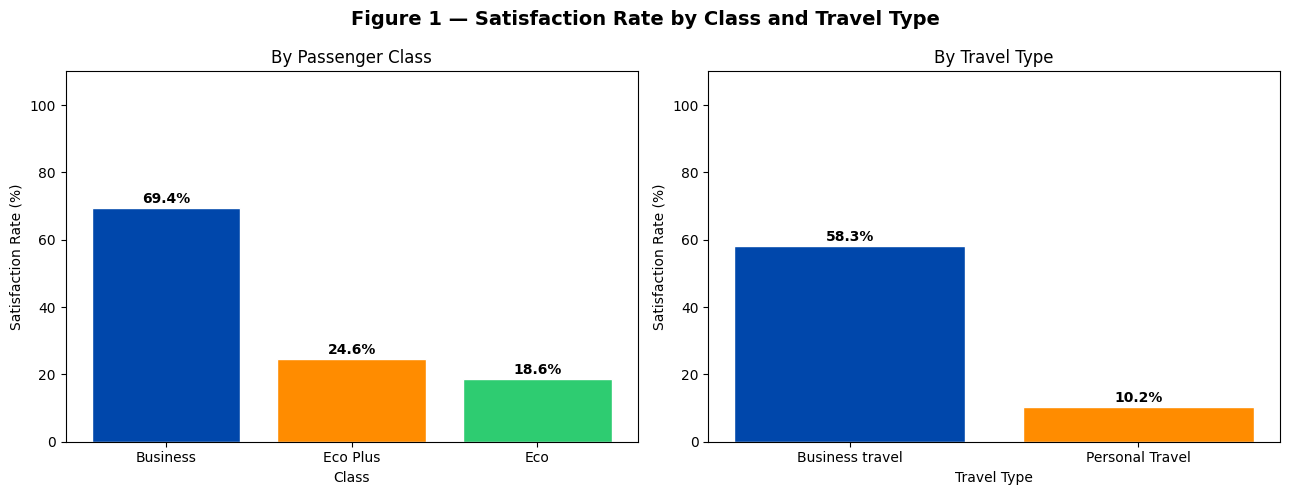

In [32]:
# Figure 1 — Satisfaction Rate by Class and Travel Type
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 1 — Satisfaction Rate by Class and Travel Type', fontsize=14, fontweight='bold')

# Left — By Class
class_data = df.groupby('class')['satisfaction_binary'].mean().mul(100).round(2).sort_values(ascending=False)
axes[0].bar(class_data.index, class_data.values, color=['#0047AB', '#FF8C00', '#2ecc71'], edgecolor='white')
axes[0].set_title('By Passenger Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Satisfaction Rate (%)')
axes[0].set_ylim(0, 110)
for i, (cls, val) in enumerate(class_data.items()):
    axes[0].text(i, val + 1.5, f'{val:.1f}%', ha='center', fontweight='bold')

# Right — By Travel Type
travel_data = df.groupby('type_of_travel')['satisfaction_binary'].mean().mul(100).round(2).sort_values(ascending=False)
axes[1].bar(travel_data.index, travel_data.values, color=['#0047AB', '#FF8C00'], edgecolor='white')
axes[1].set_title('By Travel Type')
axes[1].set_xlabel('Travel Type')
axes[1].set_ylabel('Satisfaction Rate (%)')
axes[1].set_ylim(0, 110)
for i, (typ, val) in enumerate(travel_data.items()):
    axes[1].text(i, val + 1.5, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figure1_class_travel.png', bbox_inches='tight')
plt.show()


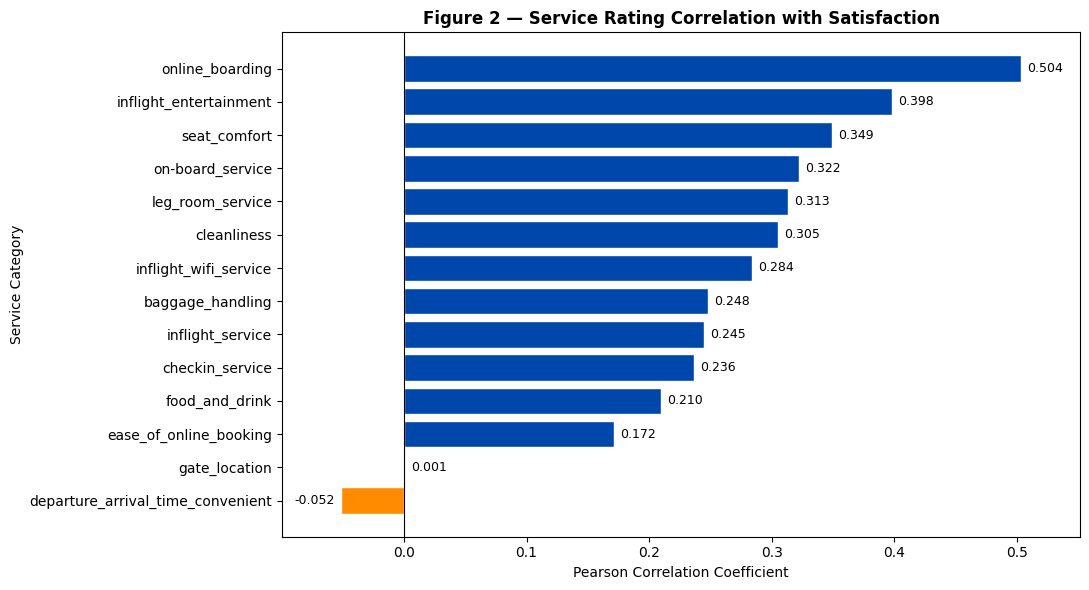

In [33]:
# Prepare correlation data
corr_series = (
    df[service_cols + ['satisfaction_binary']]
    .corr()['satisfaction_binary']
    .drop('satisfaction_binary')
    .sort_values()
)

# Plot
fig, ax = plt.subplots(figsize=(11, 6))

bar_colors = ['#0047AB' if v >= 0 else '#FF8C00' for v in corr_series.values]

ax.barh(corr_series.index, corr_series.values, color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)

# Labels on bars
for i, val in enumerate(corr_series.values):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ax.text(xpos, i, f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=9)

# Formatting
ax.set_xlim(ax.get_xlim()[0] - 0.02, ax.get_xlim()[1] + 0.02)
ax.set_title('Figure 2 — Service Rating Correlation with Satisfaction', fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_ylabel('Service Category')

plt.tight_layout()
plt.savefig('figure2_correlation.png', bbox_inches='tight')
plt.show()



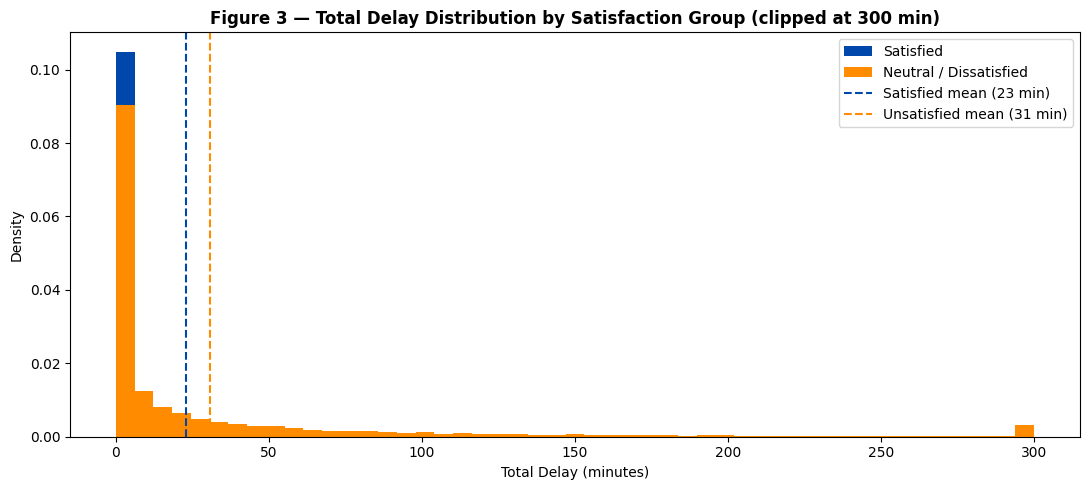

In [34]:
# Figure 3 — Total Delay Distribution by Satisfaction Group
fig, ax = plt.subplots(figsize=(11, 5))

sat_d   = df[df['satisfaction'] == 'satisfied']['total_delay'].clip(upper=300)
unsat_d = df[df['satisfaction'] == 'neutral or dissatisfied']['total_delay'].clip(upper=300)

bins = np.linspace(0, 300, 50)

ax.hist(sat_d,   bins=bins, alpha=1, density=True, color='#0047AB', label='Satisfied')
ax.hist(unsat_d, bins=bins, alpha=1, density=True, color='#FF8C00', label='Neutral / Dissatisfied')

ax.axvline(sat_d.mean(),   color='#0047AB', linestyle='--', linewidth=1.5, label=f'Satisfied mean ({sat_d.mean():.0f} min)')
ax.axvline(unsat_d.mean(), color='#FF8C00', linestyle='--', linewidth=1.5, label=f'Unsatisfied mean ({unsat_d.mean():.0f} min)')

ax.set_title('Figure 3 — Total Delay Distribution by Satisfaction Group (clipped at 300 min)', fontweight='bold')
ax.set_xlabel('Total Delay (minutes)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig('figure3_delay_dist.png', bbox_inches='tight')
plt.show()

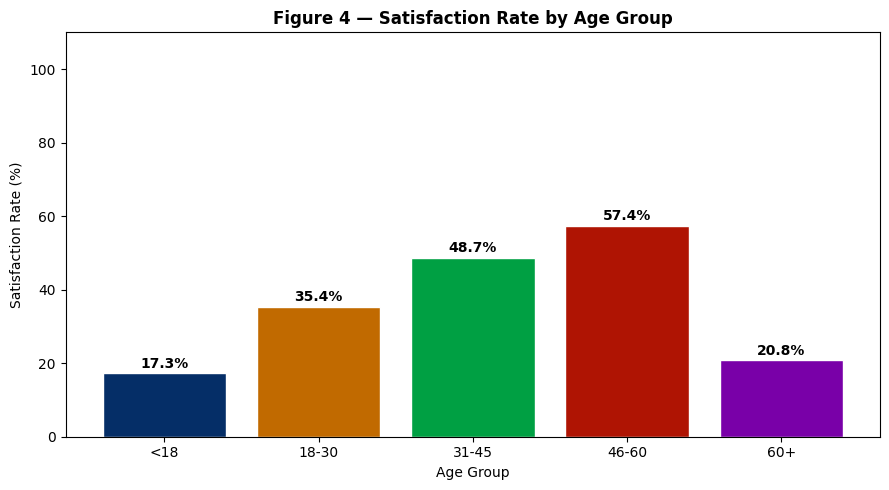

In [35]:
# Figure 4 — Satisfaction Rate by Age Group
fig, ax = plt.subplots(figsize=(9, 5))

sat_age = df.groupby('age_group', observed=True)['satisfaction_binary'].mean().mul(100)
colors  = ["#052E67", "#C16A00", "#00a043", "#af1403", "#7900a8"]

ax.bar(sat_age.index.astype(str), sat_age.values, color=colors, edgecolor='white')

for i, val in enumerate(sat_age.values):
    ax.text(i, val + 1.5, f'{val:.1f}%', ha='center', fontweight='bold')

ax.set_title('Figure 4 — Satisfaction Rate by Age Group', fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Satisfaction Rate (%)')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('figure4_age.png', bbox_inches='tight')
plt.show()


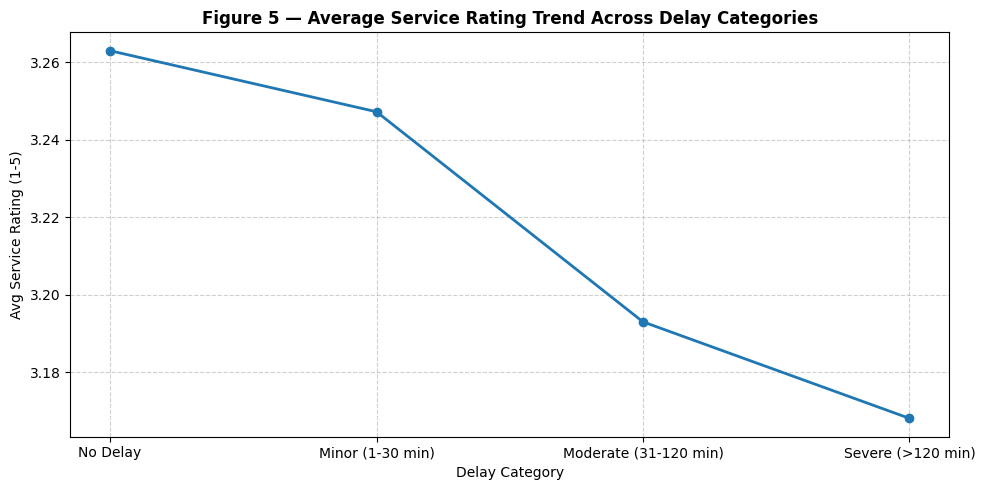

In [36]:
# Figure 5 — Satisfaction Rate by Age Group
fig, ax = plt.subplots(figsize=(10, 5))

delay_order = ['No Delay', 'Minor (1-30 min)', 'Moderate (31-120 min)', 'Severe (>120 min)']

avg_rating_delay = (
    df.groupby('delay_category', observed=True)['avg_service_rating']
    .mean()
    .reindex(delay_order)
)

ax.plot(
    avg_rating_delay.index.astype(str),
    avg_rating_delay.values,
    marker="o",
    linewidth=2
)

ax.set_xlabel("Delay Category")
ax.set_ylabel("Avg Service Rating (1-5)")
ax.set_title('Figure 5 — Average Service Rating Trend Across Delay Categories', fontweight='bold')
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig('figure5_service_rating_delay.png', bbox_inches='tight')
plt.show()

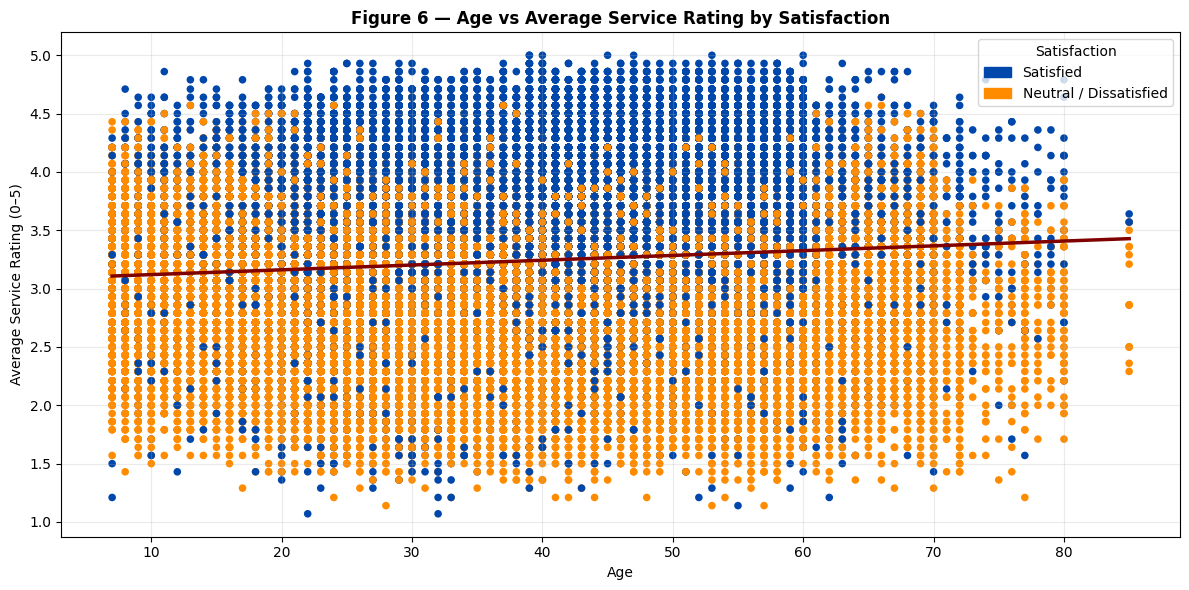

In [37]:
# Figure 6 — Age vs Average Service Rating by Satisfaction
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    df["age"],
    df["avg_service_rating"],
    c=df["satisfaction_binary"].map({1: "#0047AB", 0: "#FF8C00"}),
    s=30,
    alpha=1,
    linewidth=0
)

m, b = np.polyfit(df["age"], df["avg_service_rating"], 1)
x_vals = np.linspace(df["age"].min(), df["age"].max(), 300)
ax.plot(x_vals, m * x_vals + b, color="maroon", linewidth=2.5)

ax.set_title("Figure 6 — Age vs Average Service Rating by Satisfaction", fontweight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Average Service Rating (0–5)")
ax.grid(True, alpha=0.25)
ax.legend(handles=[
    mpatches.Patch(color="#0047AB", label="Satisfied"),
    mpatches.Patch(color="#FF8C00", label="Neutral / Dissatisfied")
], title="Satisfaction")

plt.tight_layout()
plt.savefig("figure6_scatter_age_rating.png", bbox_inches="tight")
plt.show()


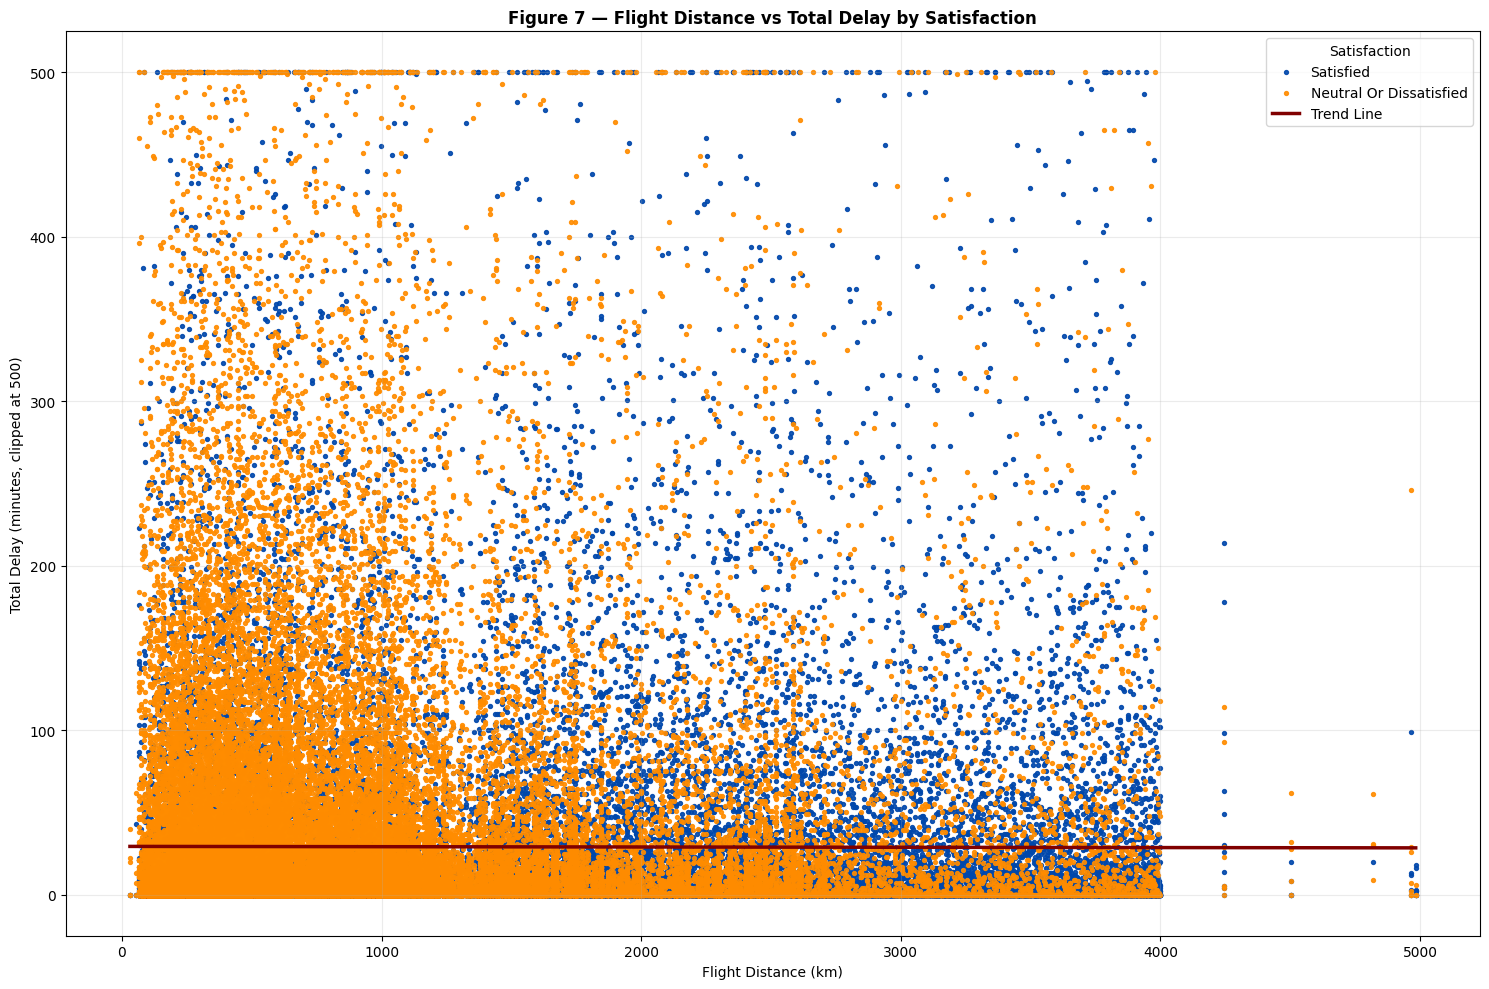

In [38]:
# Figure 7 — Flight Distance vs Total Delay by Satisfaction
fig, ax = plt.subplots(figsize=(15, 10))

for label, color in [('satisfied', '#0047AB'), ('neutral or dissatisfied', '#FF8C00')]:
    subset = df[df['satisfaction'] == label]
    ax.scatter(
        subset['flight_distance'],
        subset['total_delay'].clip(upper=500),
        alpha=0.90,
        s=8,
        color=color,
        label=label.title()
    )

m, b = np.polyfit(df['flight_distance'], df['total_delay'].clip(upper=500), 1)
x_vals = np.linspace(df['flight_distance'].min(), df['flight_distance'].max(), 300)
ax.plot(x_vals, m * x_vals + b, color='maroon', linewidth=2.5, label='Trend Line')

ax.set_title('Figure 7 — Flight Distance vs Total Delay by Satisfaction', fontweight='bold')
ax.set_xlabel('Flight Distance (km)')
ax.set_ylabel('Total Delay (minutes, clipped at 500)')
ax.grid(True, alpha=0.25)
ax.legend(title='Satisfaction')

plt.tight_layout()
plt.savefig('figure7_scatter_distance_delay.png', bbox_inches='tight')
plt.show()


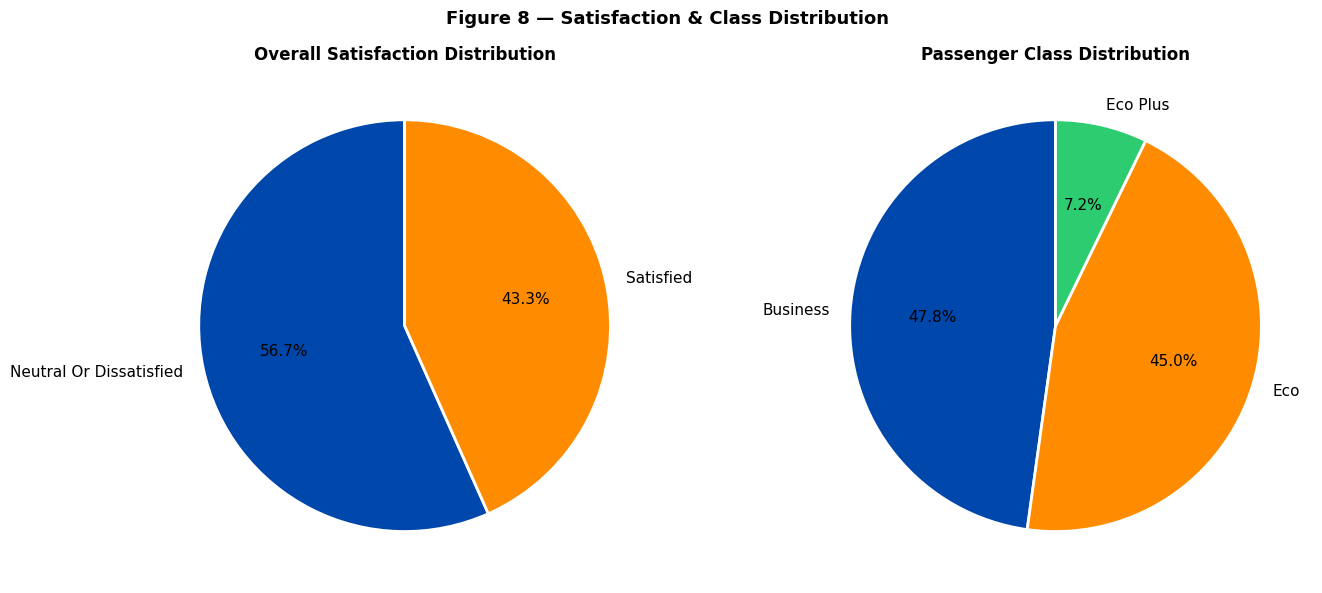

In [39]:
# Figure 8 — Satisfaction & Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — Overall Satisfaction
sat_counts = df['satisfaction'].value_counts()
axes[0].pie(
    sat_counts.values,
    labels=sat_counts.index.str.title(),
    colors=['#0047AB', '#FF8C00'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)
axes[0].set_title('Overall Satisfaction Distribution', fontweight='bold')

# Right — Passenger Class
class_counts = df['class'].value_counts()
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    colors=['#0047AB', '#FF8C00', '#2ecc71'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)
axes[1].set_title('Passenger Class Distribution', fontweight='bold')

fig.suptitle('Figure 8 — Satisfaction & Class Distribution', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('figure8_pie_charts.png', bbox_inches='tight')
plt.show()
